<a href="https://colab.research.google.com/github/Joeaviator/SHAPE_DETECTION_CV2/blob/main/SHAPE_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

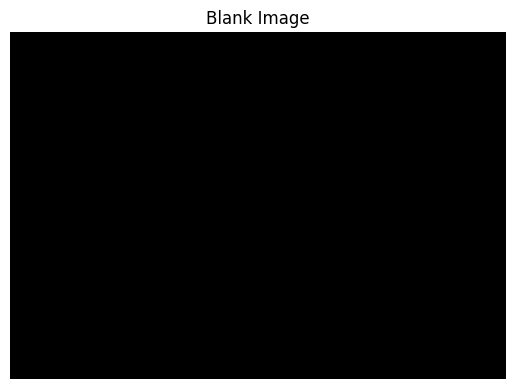

In [30]:
#Blank image
img=np.zeros((700,1000,3),dtype=np.uint8)
plt.imshow(img)
plt.title("Blank Image")
plt.axis("off")
plt.show()

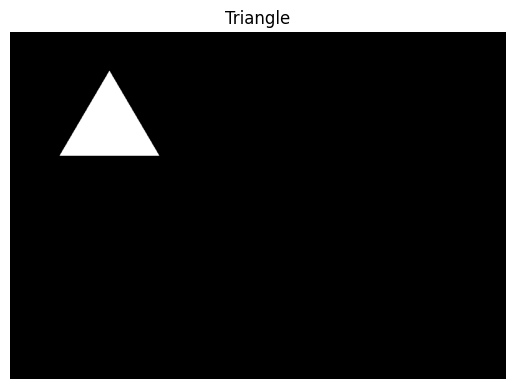

In [31]:
#Triangle
triangle=np.array([[100,250],[200,80],[300,250]],np.int32)
triangle=triangle.reshape((-1,1,2))
cv2.drawContours(img,[triangle],-1,(255,255,255),-1)
plt.imshow(img)
plt.title("Triangle")
plt.axis("off")
plt.show()

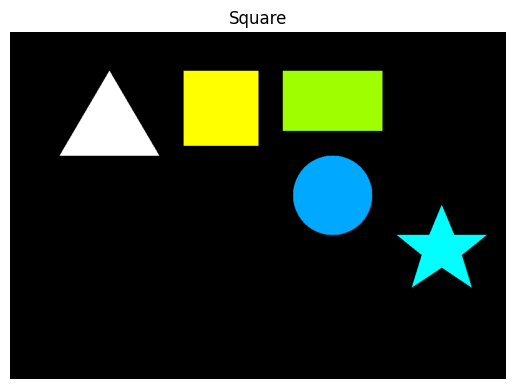

In [43]:
#Square
cv2.rectangle(img,(350,80),(500,230),(255,255,0),-1)
plt.imshow(img)
plt.title("Square")
plt.axis("off")
plt.show()

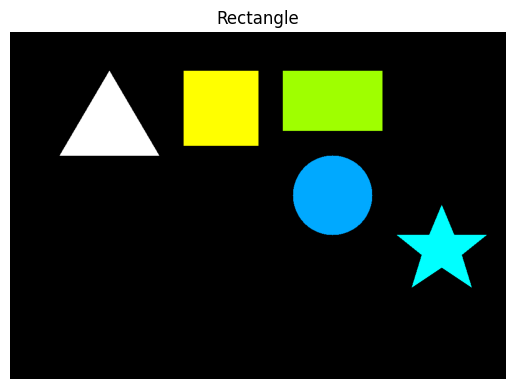

In [44]:
#Rectangle
cv2.rectangle(img,(550,80),(750,200),(159,255,0),-1)
plt.imshow(img)
plt.title("Rectangle")
plt.axis("off")
plt.show()


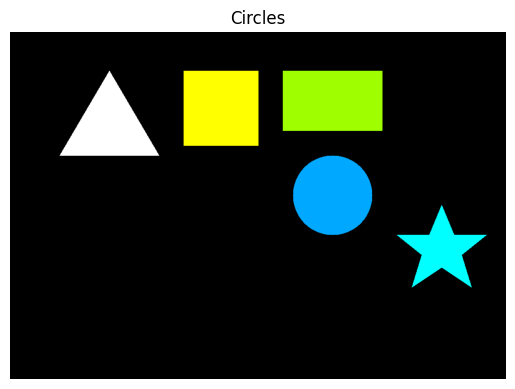

In [45]:
#Circle
cv2.circle(img,(650, 330),80,(0,169,255),-1)
plt.imshow(img)
plt.title("Circles")
plt.axis("off")
plt.show()

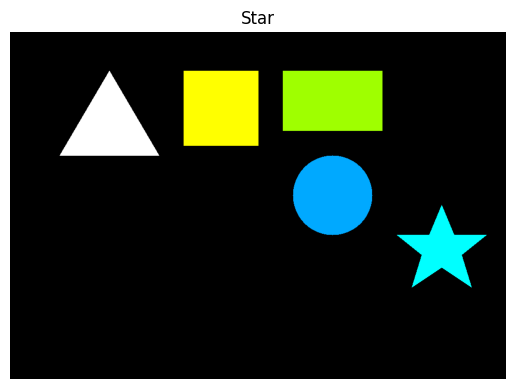

In [46]:
#Star
star=star=np.array([ [870, 350], [895, 410], [960, 410], [910, 450], [930, 515], [870, 475], [810, 515], [830, 450], [780, 410], [845, 410] ], np.int32)
star=star.reshape((-1,1,2))
cv2.drawContours(img,[star],-1,(0,255,255),-1)
plt.imshow(img)
plt.title("Star")
plt.axis("off")
plt.show()


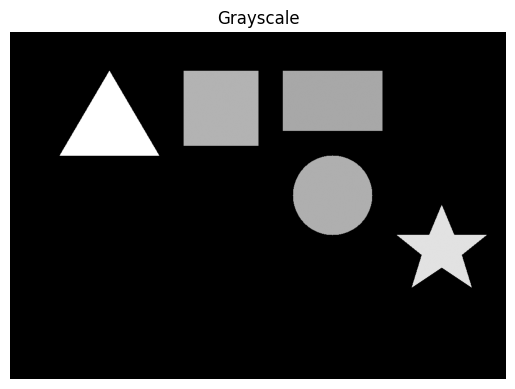

In [47]:
#Grayscale
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

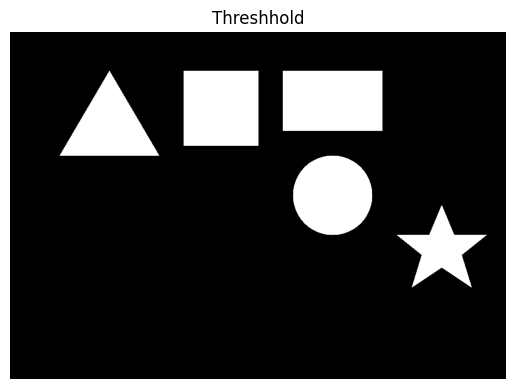

In [48]:
#Threshhold of the shapes
_,threshold=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)
plt.imshow(threshold,cmap="gray")
plt.title("Threshhold")
plt.axis("off")
plt.show()

In [50]:
#Find the contours
contours,hierachy=cv2.findContours(threshold,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
print("Number of Countours found: " ,contours)

Number of Countours found:  (array([[[870, 350]],

       [[870, 351]],

       [[869, 352]],

       [[869, 353]],

       [[868, 354]],

       [[868, 355]],

       [[867, 356]],

       [[867, 358]],

       [[866, 359]],

       [[866, 360]],

       [[865, 361]],

       [[865, 363]],

       [[864, 364]],

       [[864, 365]],

       [[863, 366]],

       [[863, 367]],

       [[862, 368]],

       [[862, 370]],

       [[861, 371]],

       [[861, 372]],

       [[860, 373]],

       [[860, 375]],

       [[859, 376]],

       [[859, 377]],

       [[858, 378]],

       [[858, 379]],

       [[857, 380]],

       [[857, 382]],

       [[856, 383]],

       [[856, 384]],

       [[855, 385]],

       [[855, 387]],

       [[854, 388]],

       [[854, 389]],

       [[853, 390]],

       [[853, 391]],

       [[852, 392]],

       [[852, 394]],

       [[851, 395]],

       [[851, 396]],

       [[850, 397]],

       [[850, 399]],

       [[849, 400]],

       [[849, 401]],

   

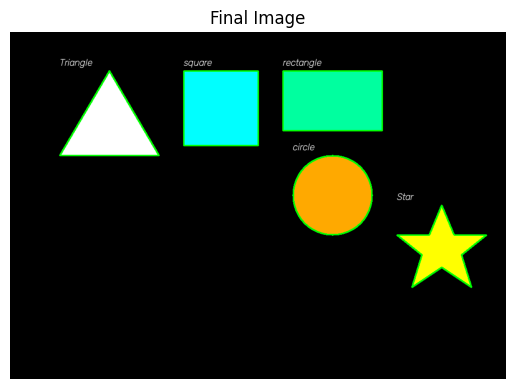

In [55]:
result=img.copy()
for contour in contours:
  #Calculatethe contour area
  area=cv2.contourArea(contour)
  if area<500:
    continue
  perimeter=cv2.arcLength(contour,True)
  #Approximate
  approx=cv2.approxPolyDP(contour,0.04*perimeter,True)
  x,y,w,h=cv2.boundingRect(approx)
  #Number ofcorners4
  corners=len(approx)
  if corners==3:
    shape="Triangle"
  elif corners==4:

    aspect_ratio=float(w)/h
    if 0.95<=aspect_ratio<=1.05:
      shape="square"
    else:
      shape="rectangle"
  elif corners==10:
    shape="Star"
  else:
    shape="circle"
  #Draw the contours
  cv2.drawContours(result,[contour],-1,(0,255,0),2)
  #
  #Write the shape name
  cv2.putText(result,shape,(x,y-10),cv2.FONT_HERSHEY_SCRIPT_SIMPLEX,0.7,(255,255,255),1)
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.title("Final Image")
plt.axis("off")
plt.show()